In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot

import gtra


from pathlib import Path


DATA_PATH = Path("/data3/projects/2025_GTRA/data/1_MND")

In [2]:
# scRNA-seq data
adata = sc.read_h5ad(DATA_PATH / "CCTSD_preproc.h5ad")
adata = adata[:,adata.var.highly_variable].copy()

# meta data (Option: answer path)
answer_path_type = "MND"
answer_path_dir =   "../answer_paths/MND_answer.csv"

In [105]:
gtra_obj = gtra.GTraObject()
gtra_obj.params.cell_type_label = "cell_type2"
gtra_obj.params.output_dir = "./MND_param_out"
gtra_obj.params.output_name = "MND_param"
gtra_obj.params.cn_cluster_resolution = 0.7
# gtra_obj.params.answer_path_type = "MND"
# gtra_obj.params.answer_path_dir = answer_path_dir

# Upload time-series scRNA_seq data
for time in sorted(adata.obs["timepoints"].unique()):
    dat = adata[adata.obs["timepoints"]==time]
    cnt_dat = dat.to_df(layer="counts")
    meta = dat.obs[[gtra_obj.params.cell_type_label]]
    gtra_obj.upload_time_scRNA(cnt_dat, meta)

gtra_obj.select_genes()

In [106]:
gtra_obj.find_gclusters()

Step 1: Identifying cell type-specific gene clusters...


In [81]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def cell_cluster_testing(x,y):
    y_true = x.obs["cell_type2"].astype(str)
    y_pred = y.obs["cluster_label"].astype(str)

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)

    print("ARI:", ari)
    print("NMI:", nmi)

In [82]:
t1_adata = adata[adata.obs["timepoints"]==11].copy()
t2_adata = adata[adata.obs["timepoints"]==13].copy()
t3_adata = adata[adata.obs["timepoints"]==15].copy()
t4_adata = adata[adata.obs["timepoints"]==17].copy()

In [83]:
adata.obs["timepoints"].unique()

array([13, 15, 11, 17])

In [84]:
cell_cluster_testing(t1_adata, gtra_obj.tp_data_dict[0])

ARI: 0.21724957751685647
NMI: 0.4101190758380938


In [85]:
cell_cluster_testing(t2_adata, gtra_obj.tp_data_dict[1])

ARI: 0.5783451854925135
NMI: 0.6381531606890971


In [86]:
cell_cluster_testing(t3_adata, gtra_obj.tp_data_dict[2])

ARI: 0.5138386652431237
NMI: 0.6066796503712703


In [87]:
cell_cluster_testing(t4_adata, gtra_obj.tp_data_dict[3])

ARI: 0.4331691900055763
NMI: 0.45875555909722443


In [88]:
import seaborn as sns

t1_heat = pd.crosstab(t1_adata.obs["cell_type2"], gtra_obj.tp_data_dict[0].obs['cluster_label'])
t2_heat = pd.crosstab(t2_adata.obs["cell_type2"], gtra_obj.tp_data_dict[1].obs['cluster_label'])
t3_heat = pd.crosstab(t3_adata.obs["cell_type2"], gtra_obj.tp_data_dict[2].obs['cluster_label'])
t4_heat = pd.crosstab(t4_adata.obs["cell_type2"], gtra_obj.tp_data_dict[3].obs['cluster_label'])

<Axes: xlabel='cluster_label', ylabel='cell_type2'>

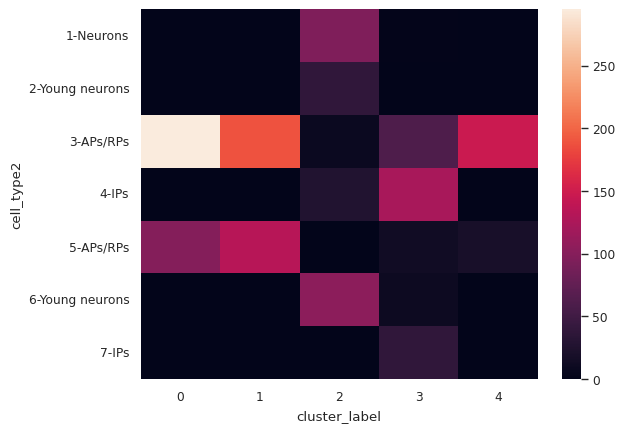

In [89]:
sns.heatmap(t1_heat)

<Axes: xlabel='cluster_label', ylabel='cell_type2'>

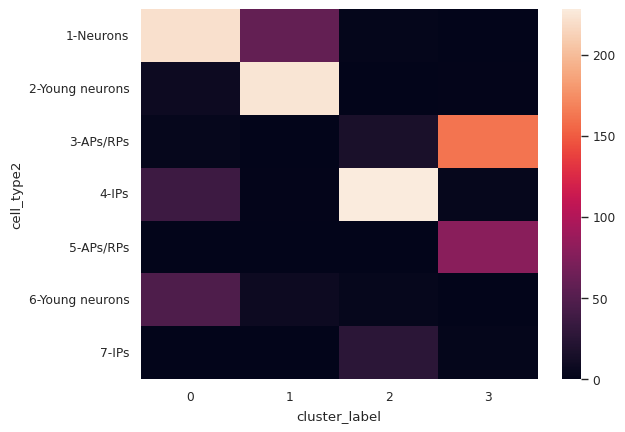

In [90]:
sns.heatmap(t2_heat)


Step 2: Constructing cell-state trajectories..:   0%|                         | 0/3 [00:00<?, ?it/s]

Step 2: Constructing cell-state trajectories..: 100%|=================| 3/3 [00:14<00:00,  4.95s/it]
Step 3: Detecting time-series pattern clustering...: 100%|==========| 36/36 [00:01<00:00, 35.65it/s]


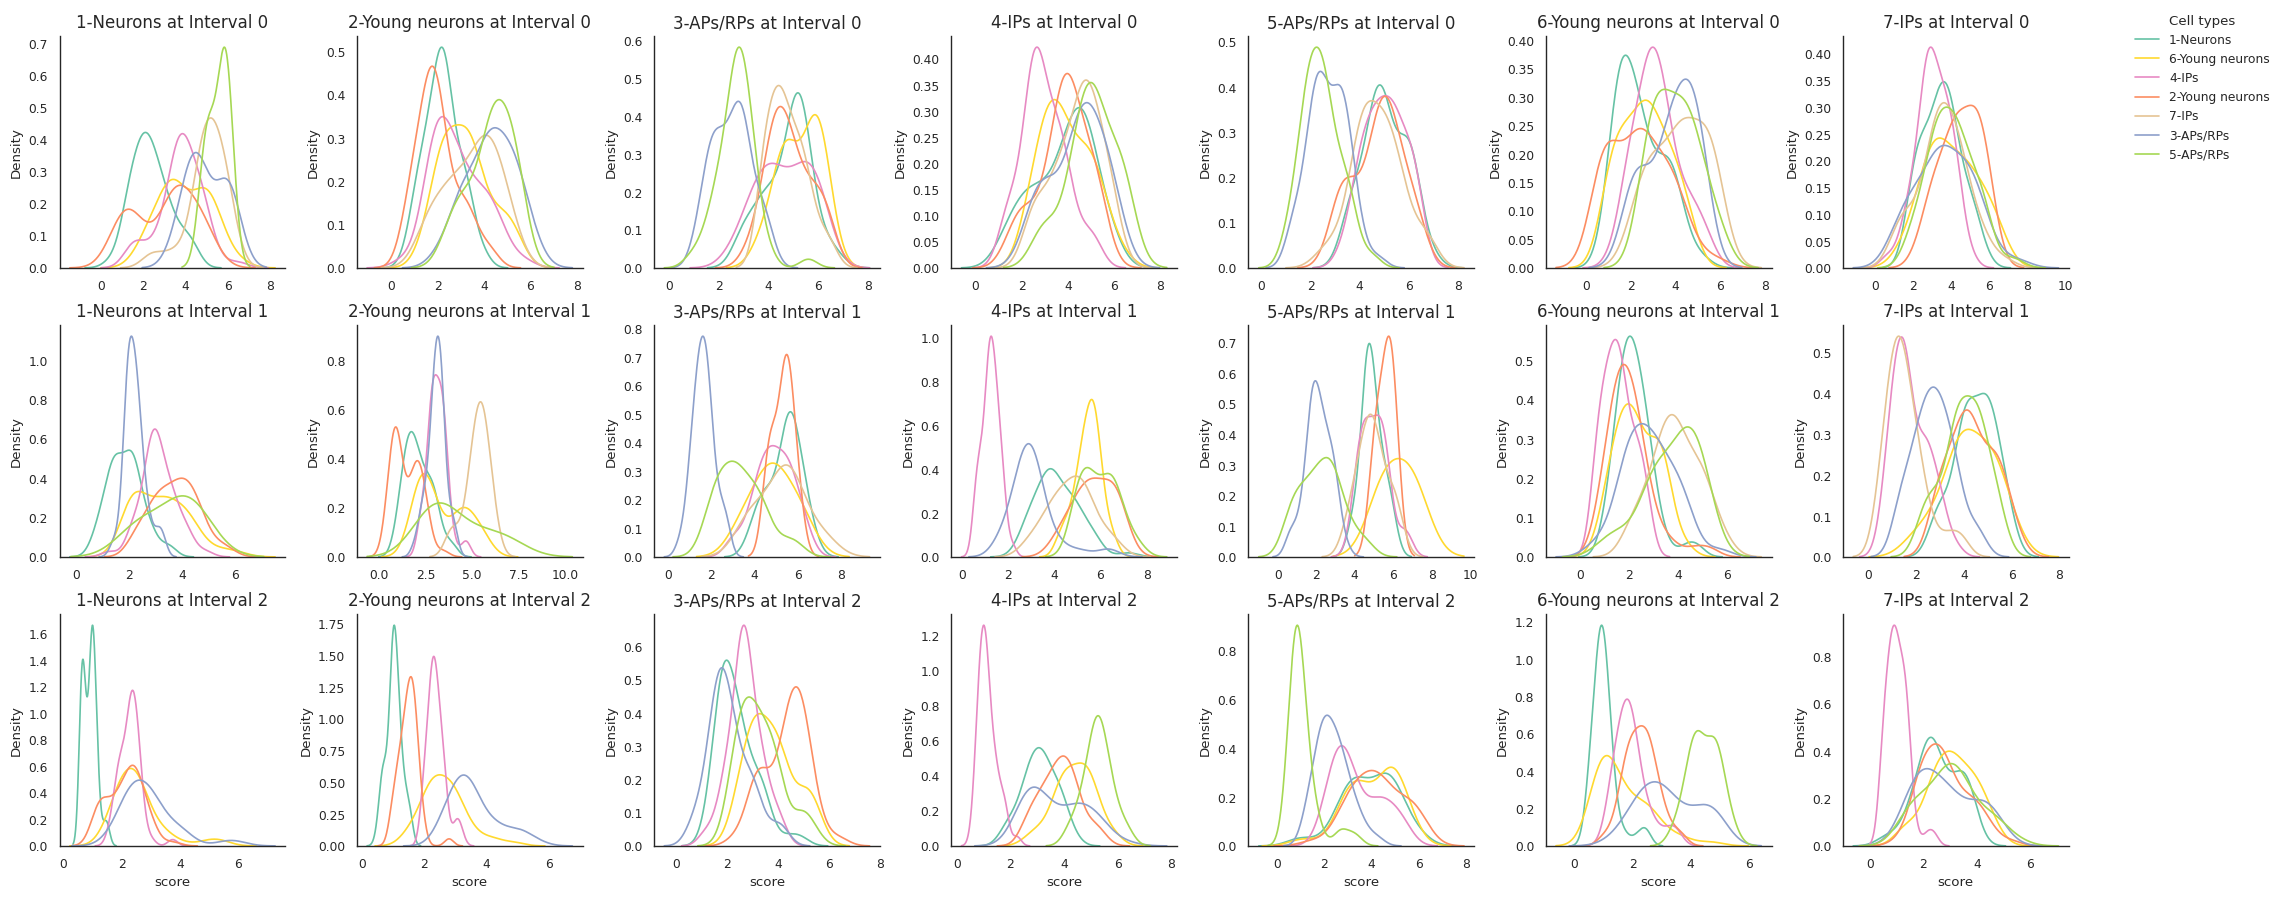

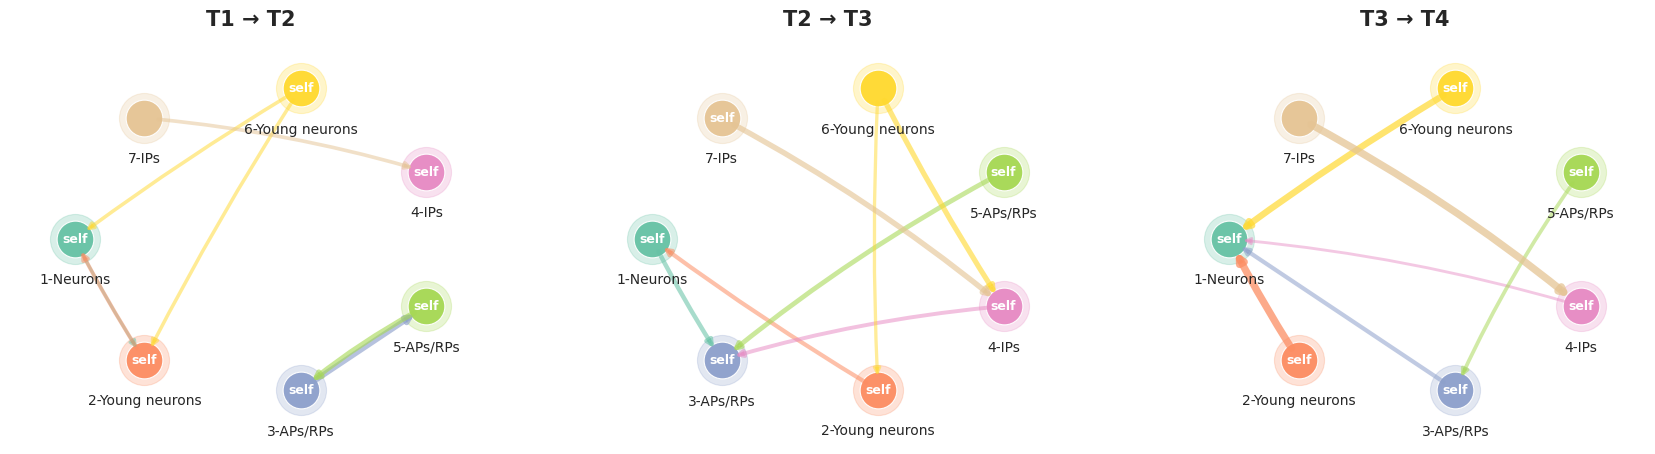

Plotting time-series gene expression patterns...


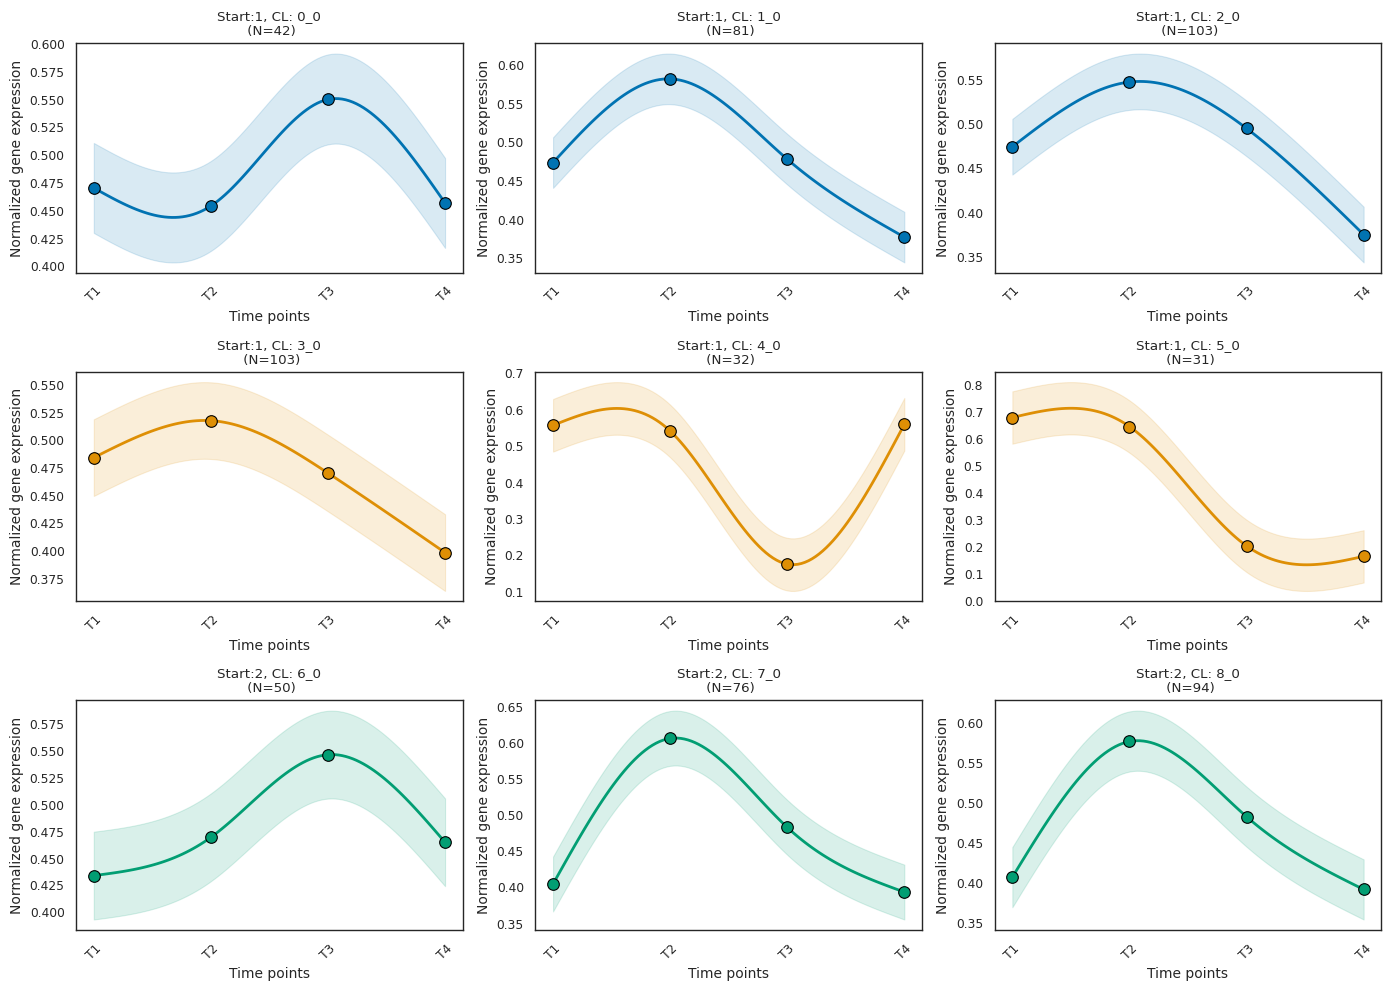

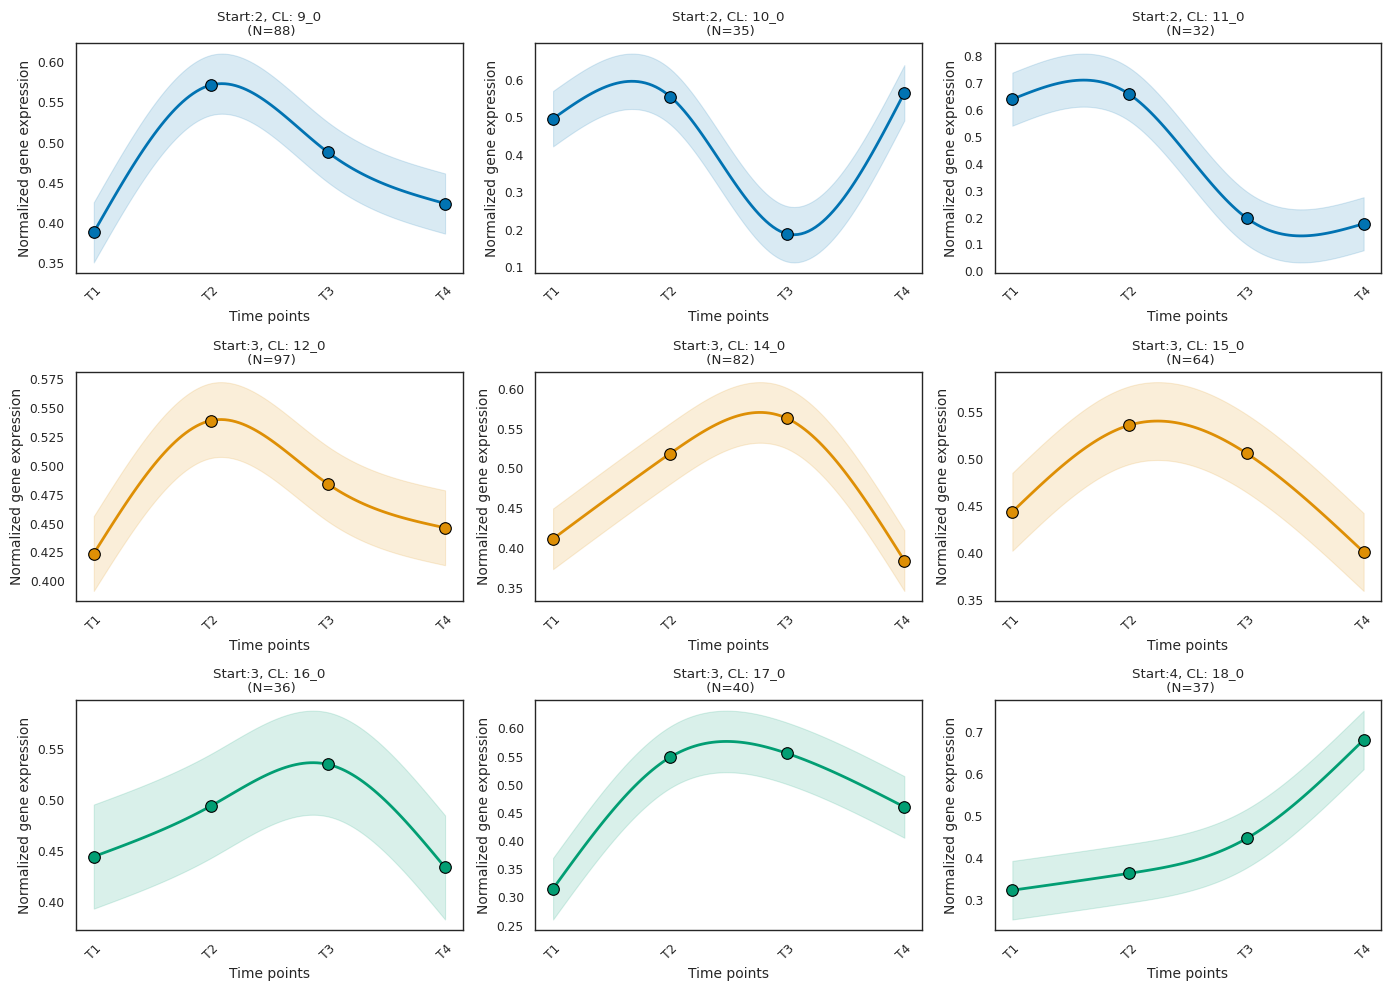

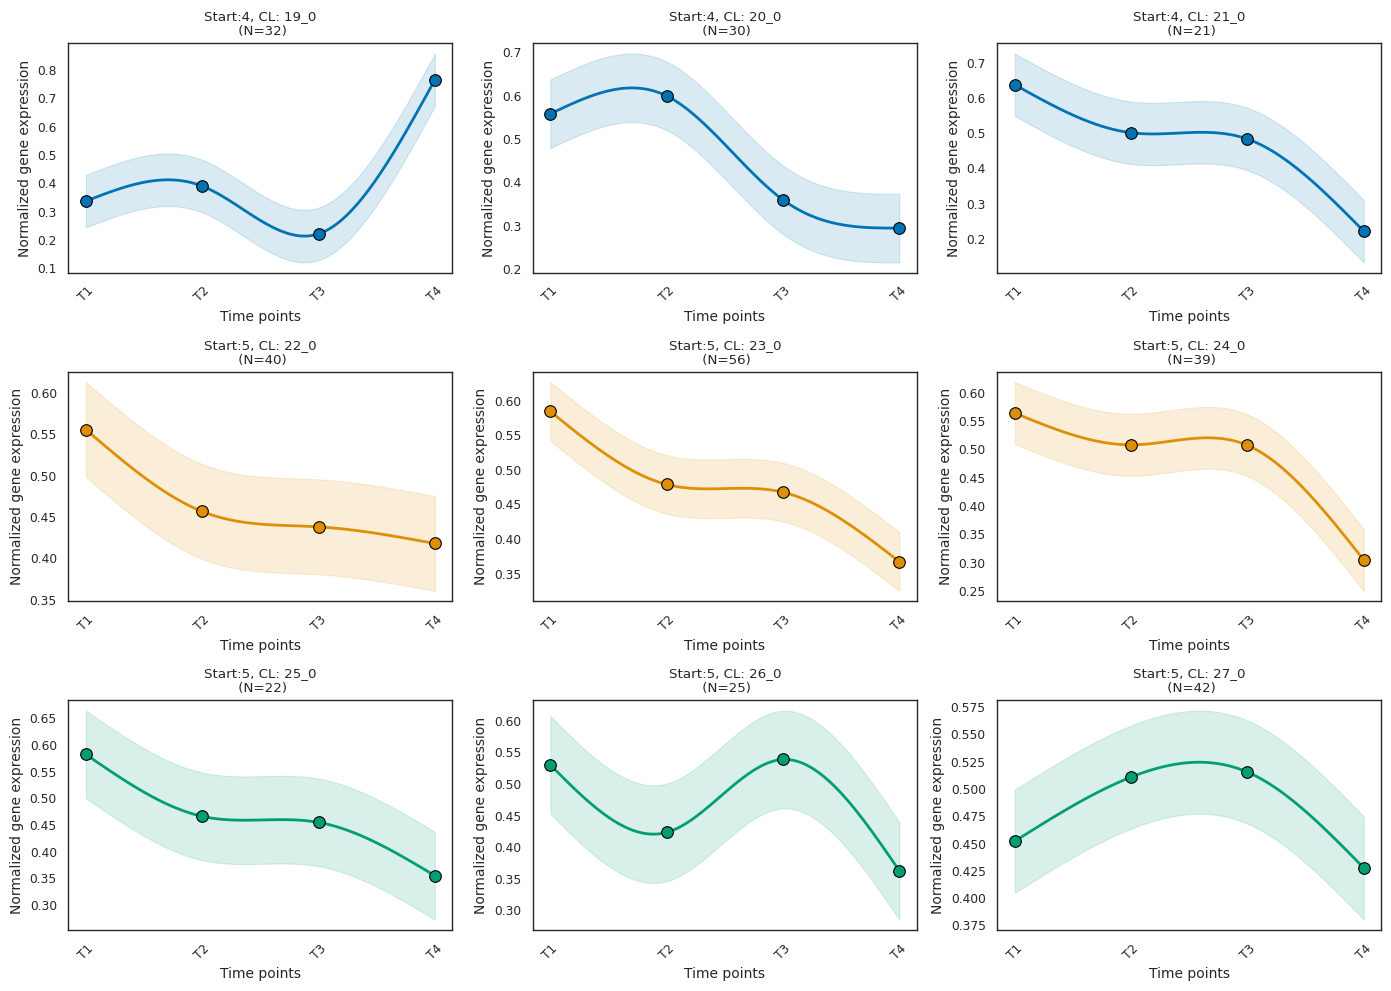

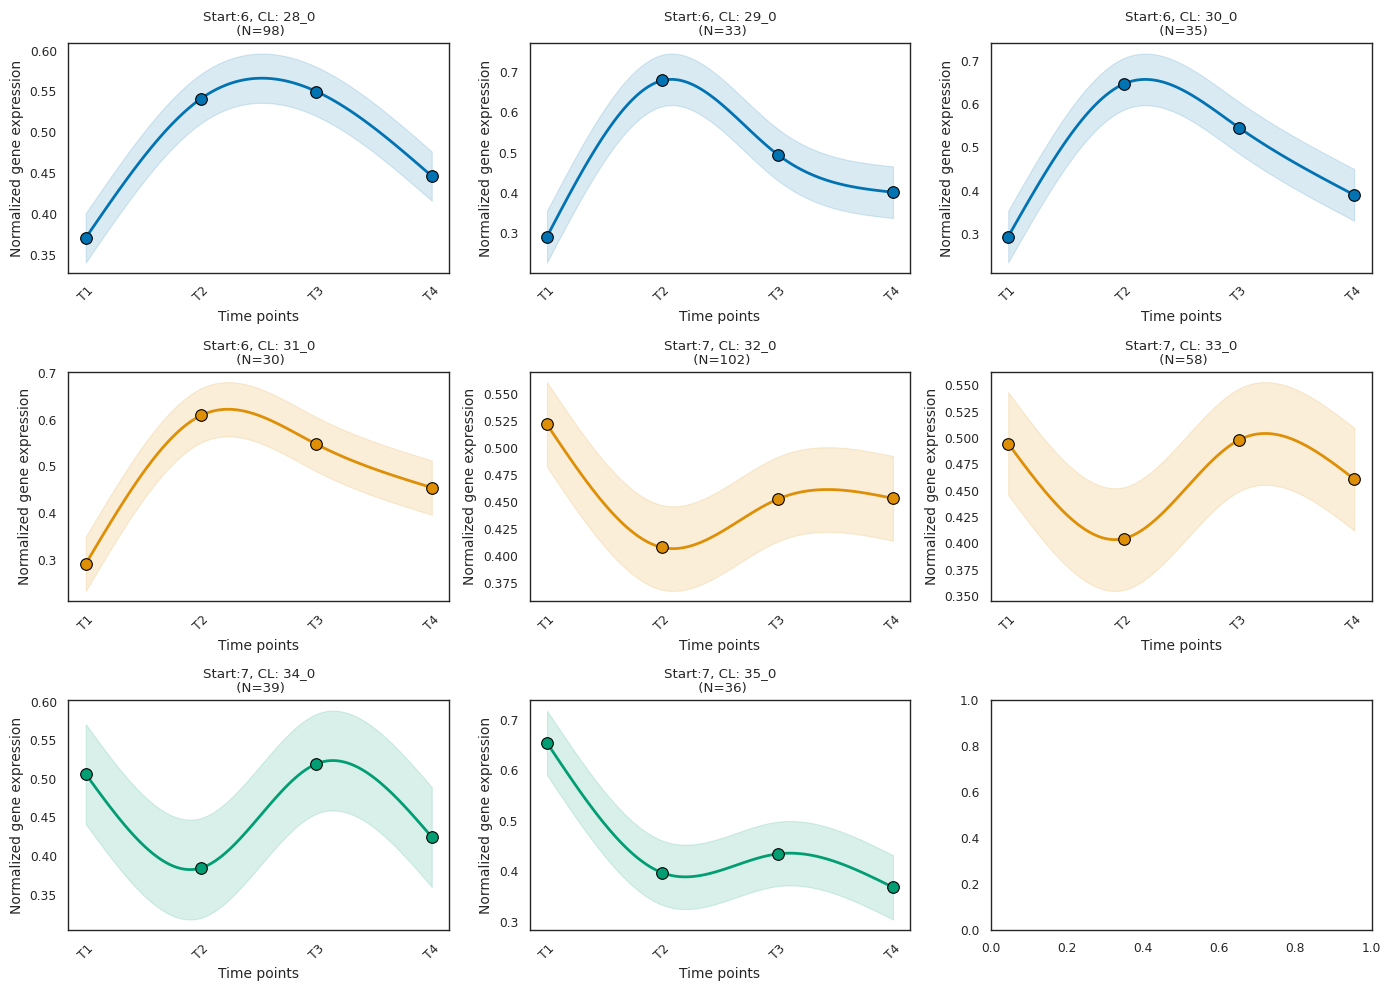

In [107]:
gtra_obj.construct_trajectories()
gtra_obj.pattern_clustering()
gtra_obj.params.time_point_label = ["T1", "T2", "T3","T4"]
gtra_obj.plot_edge_statistic()
gtra_obj.plot_cell_state_graph()
gtra_obj.plot_patterns()

In [109]:
gtra_obj.module_evaluation()

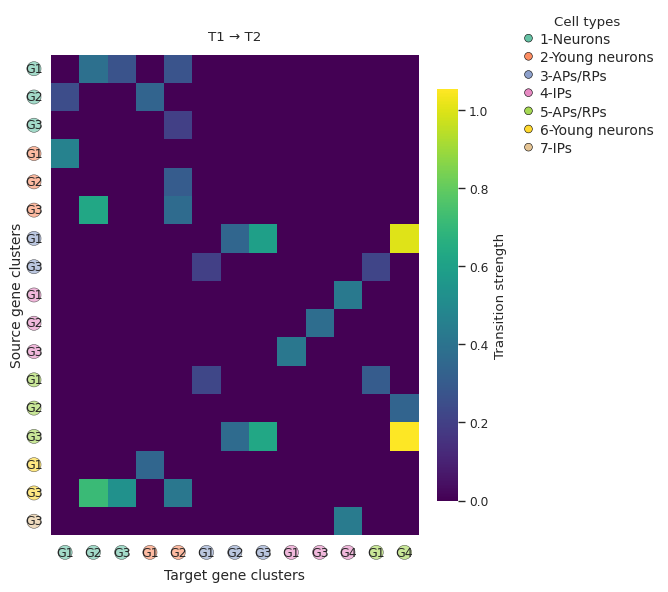

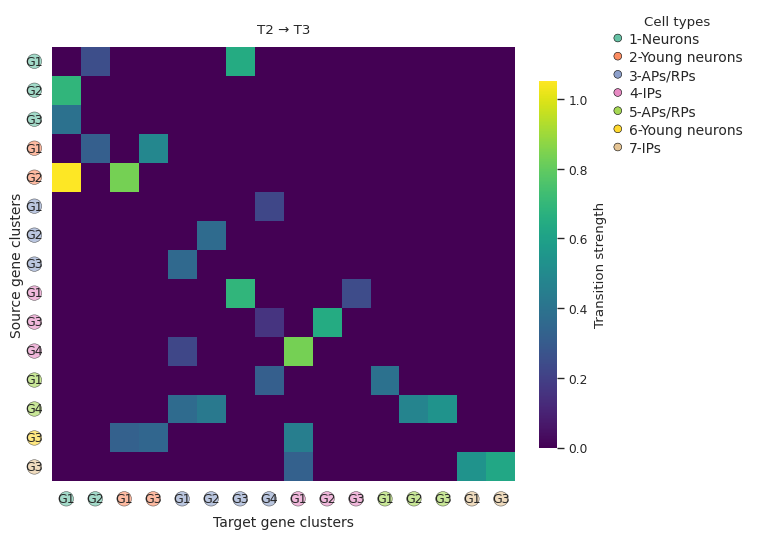

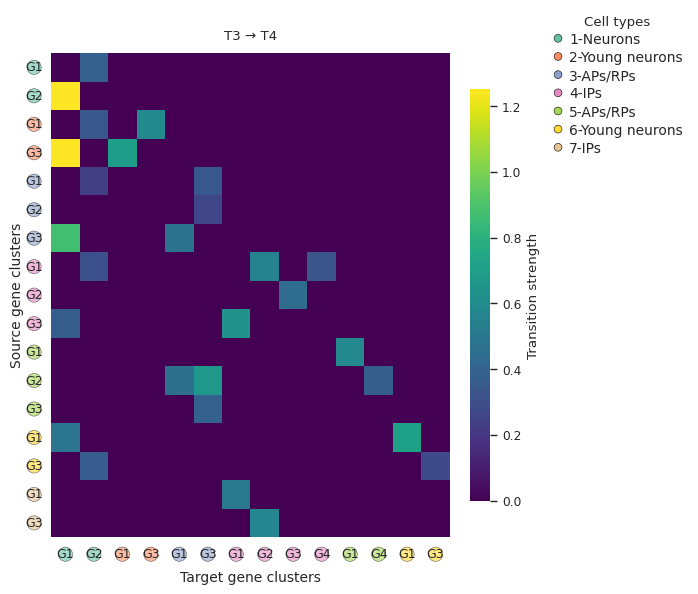

In [112]:
gtra_obj.plot_gg_matrix()

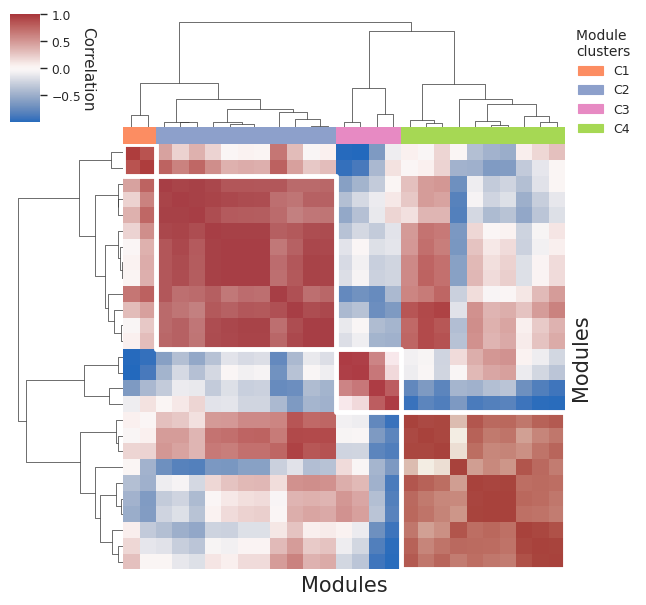

In [113]:
gtra_obj.plot_module_cluster()

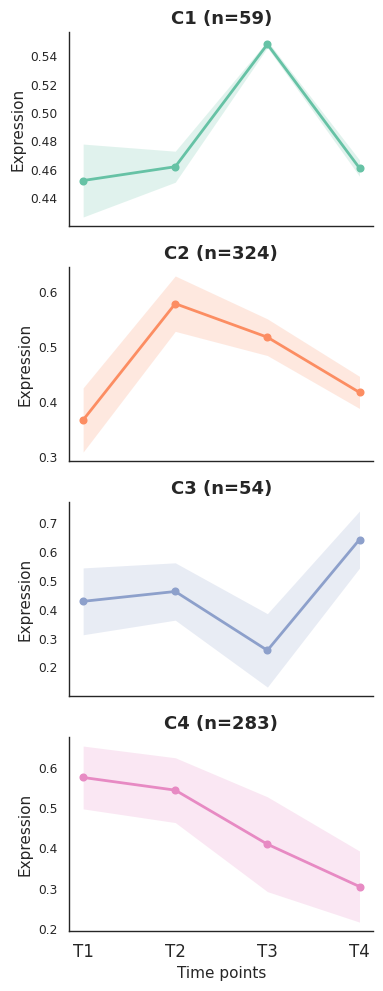

In [114]:
gtra_obj.plot_rep_patterns()